In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Loading Models Predictions

In [2]:
y_val_actual = joblib.load("../models/y_val_actual.joblib")

In [3]:
xgb_preds = joblib.load("../models/xgb_preds.joblib")

In [4]:
xgb_preds

array([19.526623, 13.029686, 15.177684, ..., 66.378296, 69.726875,
       73.09394 ], shape=(182500,), dtype=float32)

In [5]:
ulstm_preds = joblib.load("../models/lstm_preds.joblib")

In [6]:
mlstm_preds = joblib.load("../models/multi_lstm_preds.joblib")

In [7]:
print(ulstm_preds[:10])

[[17.248024]
 [13.867346]
 [13.845025]
 [14.133708]
 [15.08156 ]
 [16.322048]
 [17.860891]
 [19.791115]
 [13.767785]
 [15.897411]]


In [9]:
lgbm_preds = joblib.load("../models/lgbm_preds.joblib")

In [10]:
# align lengths 
n = min(len(y_val_actual), len(xgb_preds), len(ulstm_preds), len(mlstm_preds))
actual = y_val_actual[:n]
xgb    = xgb_preds[:n]
ulstm   = ulstm_preds[:n]
mlstm = mlstm_preds[:n]
lgbm = lgbm_preds[:n]

In [11]:
actual = np.array(actual).flatten()

# 2. Predictions Comparisions

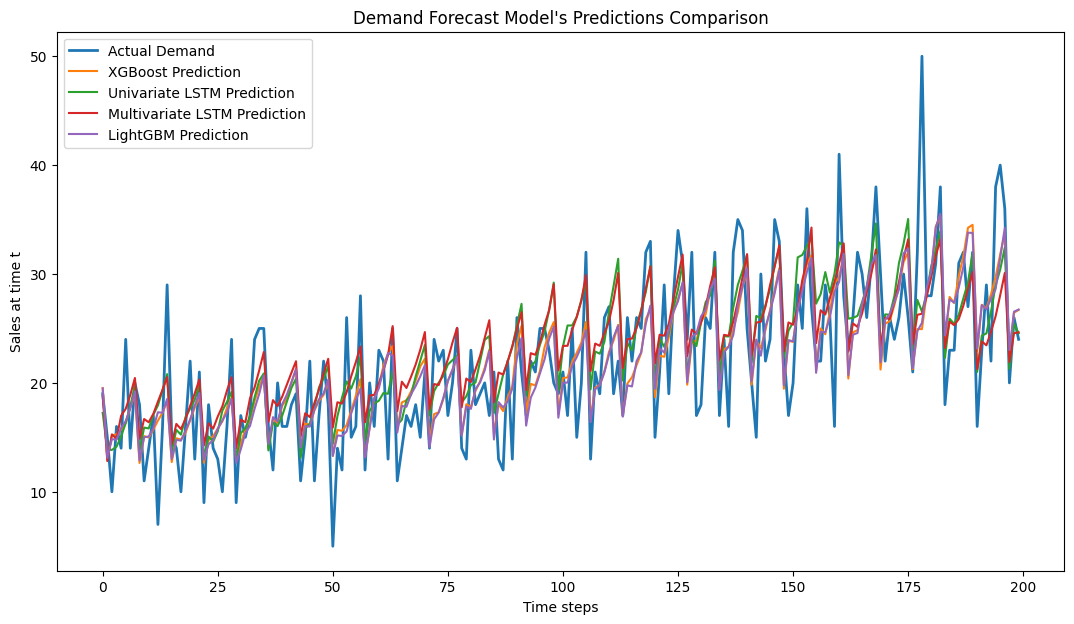

In [14]:
plt.figure(figsize=(13,7))

plt.plot(actual[:200], label="Actual Demand", linewidth=2)
plt.plot(xgb[:200], label="XGBoost Prediction")
plt.plot(ulstm[:200], label="Univariate LSTM Prediction")
plt.plot(mlstm[:200], label="Multivariate LSTM Prediction")
plt.plot(lgbm[:200], label="LightGBM Prediction")

plt.title("Demand Forecast Model's Predictions Comparison")
plt.xlabel("Time steps")
plt.ylabel("Sales at time t")
plt.legend()

plt.savefig("Demand_Forecast_Comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## ***3. Conclusion & Summary***

| Model                  | RMSE ↓  | MAPE (%) ↓ |
|------------------------|---------|------------|
| Univariate LSTM        | 8.7666  | 13.9078    |
| Multivariate LSTM      | 8.3659  | 13.1059    |
| **XGBoost (Best)**     | **7.9126** | **12.4361** |
| LightGBM               | 7.9421  | 12.5623    |